# Task 5 — Machine Learning Classification Model

## Netflix Content Type Classification

### Objective

The objective of this task is to build a machine learning classification model that predicts whether a Netflix title is a Movie or a TV Show based on available dataset features.

### Workflow

1. Select and prepare relevant features.
2. Split the dataset into training and testing sets.
3. Train multiple classification models.
4. Evaluate model performance.
5. Compare model accuracy and other evaluation metrics.

### Target Variable

- `type`

Target classes:

- Movie
- TV Show

### Classification Models

- Logistic Regression
- Decision Tree
- Random Forest

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

### Tools & Libraries

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/netflix_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (8790, 14)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90,min
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1,Season
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,1,Season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,125,min


In [3]:
print("Target Variable Distribution:")
print(df["type"].value_counts())

print("\nTarget Variable Percentage:")
print(
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target Variable Distribution:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64

Target Variable Percentage:
type
Movie      69.69
TV Show    30.31
Name: proportion, dtype: float64


In [4]:
features = [
    "release_year",
    "rating",
    "duration_value",
    "duration_unit",
    "country"
]

target = "type"

X = df[features].copy()
y = df[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['release_year', 'rating', 'duration_value', 'duration_unit', 'country']

Target:
type


In [5]:
print("Missing values in selected features:")
print(X.isnull().sum())

Missing values in selected features:
release_year        0
rating              0
duration_value      0
duration_unit       0
country           287
dtype: int64


In [6]:
numeric_features = [
    "release_year",
    "duration_value"
]

categorical_features = [
    "rating",
    "duration_unit",
    "country"
]

In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 7032
Testing samples: 1758


In [9]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy, 4))

Logistic Regression Accuracy: 1.0


In [10]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=10
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Accuracy:",
      round(decision_tree_accuracy, 4))

Decision Tree Accuracy: 1.0


In [11]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            max_depth=15,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Accuracy:",
      round(random_forest_accuracy, 4))

Random Forest Accuracy: 1.0


In [12]:
models_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions
}

evaluation_results = []

for model_name, predictions in models_predictions.items():

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            pos_label="TV Show"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            pos_label="TV Show"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            pos_label="TV Show"
        )
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


In [13]:
evaluation_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = evaluation_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].round(4)

evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


In [14]:
for model_name, predictions in models_predictions.items():

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions
        )
    )

Logistic Regression
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758

Decision Tree
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758

Random Forest
              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00   

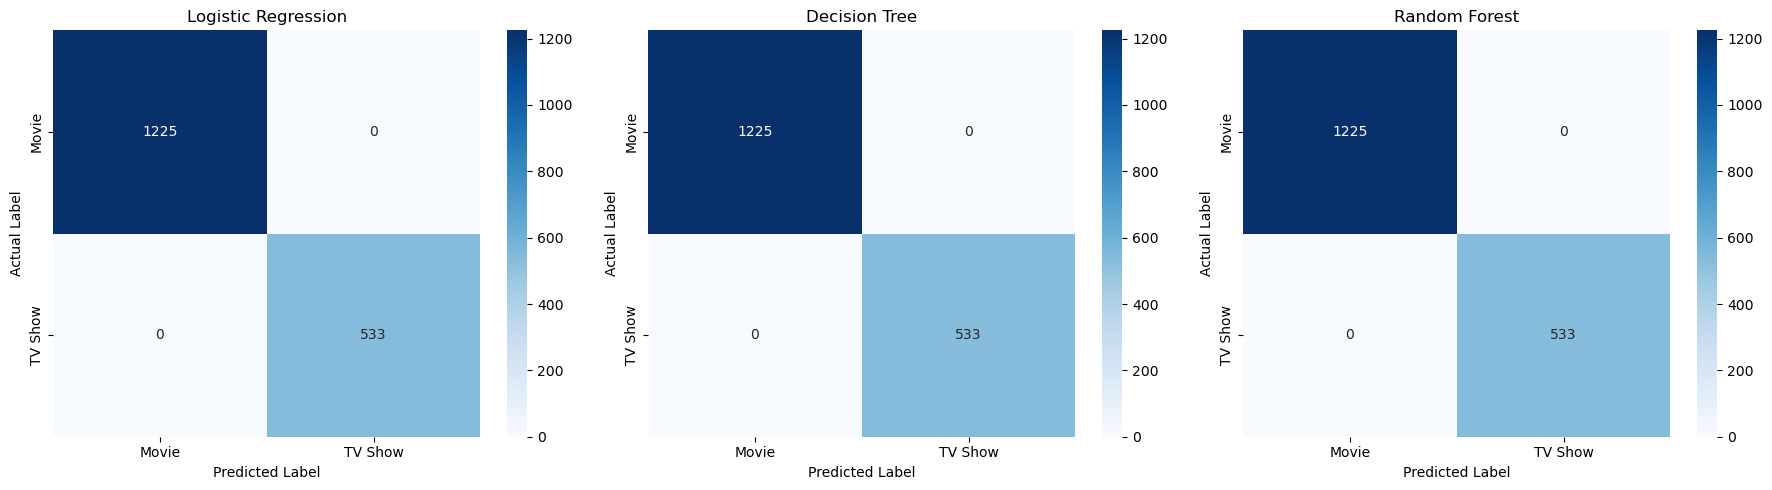

In [15]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, (model_name, predictions) in zip(
    axes,
    models_predictions.items()
):

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=["Movie", "TV Show"]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Movie", "TV Show"],
        yticklabels=["Movie", "TV Show"],
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "../outputs/task_5_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

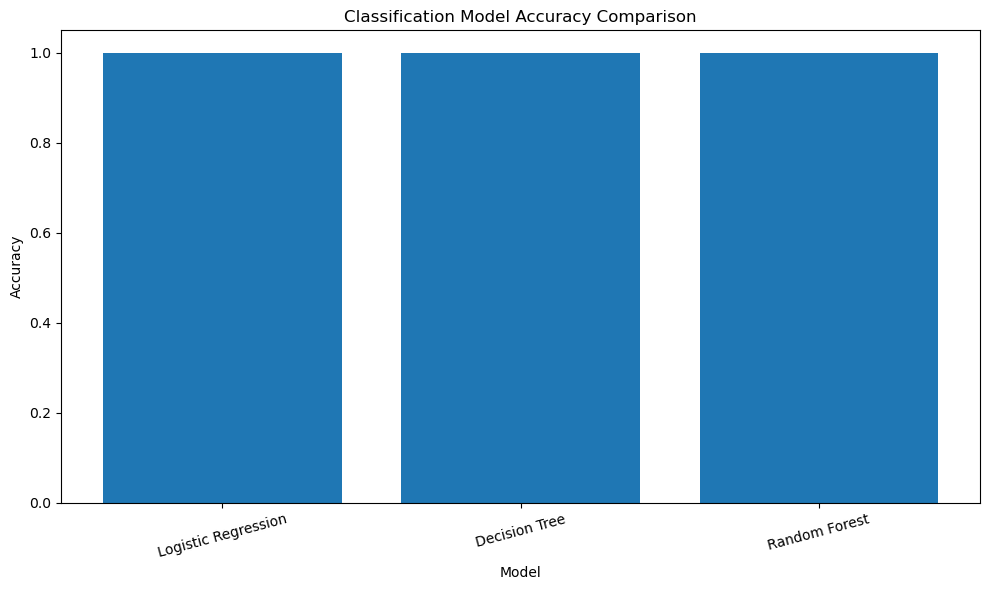

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    evaluation_df["Model"],
    evaluation_df["Accuracy"]
)

plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../outputs/task_5_model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
evaluation_df.to_csv(
    "../outputs/task_5_model_evaluation.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [18]:
best_model = evaluation_df.loc[
    evaluation_df["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = evaluation_df["Accuracy"].max()

print("Best Model:", best_model)
print("Best Accuracy:", round(best_accuracy, 4))

Best Model: Logistic Regression
Best Accuracy: 1.0


In [19]:
evaluation_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest,1.0,1.0,1.0,1.0


In [20]:
evaluation_df.to_csv(
    "../outputs/task_5_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


## Task 5 — Results, Evaluation & Interpretation

### Classification Objective

A machine learning classification system was developed to predict whether a Netflix title is a **Movie** or a **TV Show**.

The target variable was `type`, while the input features included:

- Release year
- Rating
- Duration value
- Duration unit
- Country

Categorical features were encoded using One-Hot Encoding, while numerical features were imputed and standardized using a preprocessing pipeline.

### Data Split

The dataset was divided into:

- Training samples: 7,032
- Testing samples: 1,758

A stratified train-test split with an 80:20 ratio was used to maintain the class distribution between training and testing data.

### Models Trained

Three classification algorithms were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

### Model Performance

All three models achieved an accuracy of **100%** on the test dataset.

| Model | Accuracy |
|---|---:|
| Logistic Regression | 100% |
| Decision Tree | 100% |
| Random Forest | 100% |

Precision, Recall, and F1-score were also evaluated to provide a more comprehensive assessment of classification performance.

### Best Model

Logistic Regression was selected as the preferred baseline model because it achieved the same **100% test accuracy** as the Decision Tree and Random Forest while being simpler and computationally less complex.

Since all three models achieved identical evaluation results, the selection should not be interpreted as Logistic Regression being more accurate than the other models.

### Interpretation

The perfect test-set performance indicates that the selected features contain strong information for distinguishing between Movies and TV Shows in this dataset.

Features such as duration unit, rating, and other metadata provide useful signals for identifying the content type.

### Limitations

Although the models achieved 100% test accuracy, this result should be interpreted carefully.

1. The dataset is a catalog dataset rather than a randomly generated real-world production stream.
2. Some features may contain information strongly associated with the target variable.
3. Perfect test accuracy can indicate a very easy classification problem or potential feature-target dependency.
4. Additional validation on an independent external dataset would be useful before using the model in a real production environment.
5. Accuracy alone is not sufficient for evaluating a production machine learning system.

### Conclusion

The classification task successfully demonstrated an end-to-end machine learning workflow, including feature selection, preprocessing, train-test splitting, model training, evaluation, and model comparison.

Logistic Regression, Decision Tree, and Random Forest all achieved **100% accuracy** on the test set. Logistic Regression was selected as the preferred baseline because it provides the same predictive performance with a simpler model structure.

The task demonstrates practical use of Scikit-learn classification algorithms and model validation techniques for Netflix content classification.